# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones — Edición 2026**

## Mentoría 15: *¿Cuándo y dónde pescar centollas en el Canal Beagle?*
### Trabajo Práctico 3 — Aprendizaje no supervisado (versión corregida)

**Objetivo:** caracterizar los puntos de muestreo según la abundancia y las características de los ejemplares capturados, agruparlos con técnicas no supervisadas, describir su variabilidad temporal y redactar una recomendación para el gobierno local que apunte a la persistencia del recurso.

**Consignas**
1. Caracterizar los puntos de muestreo considerando los ejemplares pescados y la variabilidad temporal.
2. Agrupar los puntos de muestreo mediante técnicas no supervisadas.
3. Describir la variabilidad temporal.
4. Redactar una recomendación para el gobierno local.

## Resumen ejecutivo

*(Los valores citados se calculan en las secciones indicadas.)*

- **Unidad de análisis.** Se trabaja con **57 puntos de muestreo** de centollón (*Paralomis granulosa*), cada uno descrito por su abundancia y la estructura de su captura. Se agrupan puntos, no individuos (§4).
- **Estructura de grupos débil.** Los datos se parecen más a un gradiente continuo que a grupos bien separados (estadístico de Hopkins ≈ 0,6). La partición mejor respaldada es **k = 2**: es la más estable en el bootstrap, los dos algoritmos coinciden y se mantiene con otros conjuntos de variables (§6–§8).
- **Los dos tipos de punto (§9):**
  - **Tipo A, machos chicos (21 puntos):** más machos por trampa pero más chicos (talla mediana ≈ 77 mm), pocas hembras en la captura (≈ 17 %) y menor proporción de hembras vulnerables (≈ 65 %).
  - **Tipo B, alta carga reproductiva (36 puntos):** machos más grandes (≈ 85 mm), más hembras en la captura (≈ 43 %) y una proporción muy alta de hembras ovígeras o postovígeras (≈ 86 %).
- **La tipología mezcla lugar y momento (§11).** El tipo de un punto depende de la campaña (los 7 puntos de jul_96 son tipo A; en oct_98, 13 de 14 son tipo B), así que los grupos **no son atributos fijos del lugar**. Ningún nombre de localización se repite, pero agrupando puntos cercanos en **zonas de 2 km** se puede seguir una misma zona en el tiempo. En las zonas visitadas en **octubre de 1996 y octubre de 1998**, en 1998 hay más hembras vulnerables (en las 4 zonas) y machos más grandes (en 3 de 4). Como se compara el mismo mes, se trata de un **cambio entre años**, no de un efecto estacional.
- **Recomendación (§12):** mantener la tolerancia cero y sumar medidas espaciales en las zonas que se mantienen como tipo B, vigilar las zonas persistentemente tipo A y, como condición para evaluar cualquier medida, instalar un **monitoreo con estaciones fijas**, que hoy no existe.

## Correcciones respecto de la versión anterior

| # | Problema de la versión anterior | Corrección aplicada | Sección |
|---|---|---|---|
| 1 | Se agrupaban 8.860 individuos; los clusters reproducían las campañas. | Se agrupan los 57 puntos de muestreo. La campaña queda fuera del modelo y se usa para describir. | §4, §7 |
| 2 | El IAR tomaba las trampas del primer lance (`'first'`) y se inflaba (E. I. Martillo: 448). | IAR = suma de capturas / suma de trampas, calculado sobre todos los lances (E. I. Martillo: 135,8, igual que en el TP2). | §4 |
| 3 | Se imputaba el esfuerzo con la mediana y `num_trampas` entraba al modelo. | Los registros sin esfuerzo no entran al IAR; el esfuerzo solo aparece dentro del IAR. | §4 |
| 4 | `rk` como índice (6.632 duplicados) rompía los cruces. | Índice posicional único. | §3 |
| 5 | Talla legal de 80 mm sin fuente; el código 7 de huevos clasificado de dos maneras. | Talla de machos como variable continua; códigos reproductivos definidos una sola vez. | §2, §5 |
| 6 | k fijado de antemano; FAMD reteniendo el 47 %; afirmaciones sin sustento. | Prueba de tendencia de agrupamiento, comparación con un modelo nulo, BIC, estabilidad por bootstrap y análisis de sensibilidad. | §6–§8 |
| 7 | Comentarios copiados de un asistente, celdas vacías, instalaciones dispersas. | Notebook reproducible de punta a punta, sin dependencias externas fuera de las de Colab. | — |

## 1. Configuración

In [1]:
import os
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (adjusted_rand_score, silhouette_samples,
                             silhouette_score)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.float_format = '{:.2f}'.format

SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

### Constantes del análisis

Todos los criterios biológicos se definen **una única vez** acá y se reutilizan en todo el notebook:

- **Códigos de huevos:** se clasifican igual que en el TP2. Ovígera: 1, 2, 3, 30, 4, 40, 6. Postovígera: 5 y 7 (trazas). Vulnerables: la unión de ambos grupos.
- **Umbrales de madurez:** son los provistos por la mentora (LC en mm).
- **Equivalencia de esfuerzo:** 1 línea = 10 trampas, dato de la mentora.

In [2]:
COD_OVIGERAS = [1, 2, 3, 30, 4, 40, 6]
COD_POSTOVIGERAS = [5, 7]
COD_VULNERABLES = COD_OVIGERAS + COD_POSTOVIGERAS

MADUREZ_MACHO_MM = 50.2
MADUREZ_HEMBRA_MM = 60.6
TRAMPAS_POR_LINEA = 10

ORDEN_CAMPANAS = ['ene_96', 'abril_96', 'jul_96', 'oct_96', 'jul_97', 'oct_97', 'oct_98']

## 2. Carga y curación de datos

Se reproducen las decisiones de limpieza del TP2, sin cambios de criterio:
- se eliminan los registros sin largo de caparazón y los que no tienen ninguna referencia espacial;
- se corrigen los valores de texto de `huevos` y se descarta el registro `po`;
- el estudio se restringe al centollón, porque las centollas son menos del 3 % de los registros.

Los datos se leen del repositorio local si existen y, si no, desde GitHub (por ejemplo, al abrir el notebook en Colab).

In [3]:
def leer_csv(ruta_local, url, **kwargs):
    origen = ruta_local if os.path.exists(ruta_local) else url
    return pd.read_csv(origen, sep=';', engine='python', **kwargs)


original = leer_csv('datos/centollas_mentoria.csv',
                    'https://raw.githubusercontent.com/luciabergagna-jpg/centoll/main/centollas_mentoria.csv',
                    encoding='latin1')
jul97 = leer_csv('datos/jul97.csv',
                 'https://raw.githubusercontent.com/Mariano-ds/centollas2026/main/datos/jul97.csv',
                 encoding='utf-8-sig')

for tabla in (original, jul97):
    tabla.columns = tabla.columns.str.strip().str.lower()

crudo = pd.concat([original, jul97], ignore_index=True)
print(f'Registros crudos: {len(crudo):,}')

Registros crudos: 13,114


In [4]:
def extraer_num_trampas(tipo):
    # Devuelve el esfuerzo en trampas o NaN si el tipo de captura no declara cantidad.
    texto = str(tipo).lower()
    m = re.search(r'(\d+\.?\d*)\s*(?:de\s*)?(trampa|línea|linea)', texto)
    if m is None:
        m2 = re.search(r'(trampa|línea|linea)s?\s*(?::\s*|de\s*)?(\d+\.?\d*)', texto)
        if m2 is None:
            return np.nan
        unidad, valor = m2.group(1), float(m2.group(2))
    else:
        valor, unidad = float(m.group(1)), m.group(2)
    return valor * TRAMPAS_POR_LINEA if unidad.startswith('l') else valor


df = crudo.drop(columns=[c for c in crudo.columns if c.startswith('unnamed')])
df = df.dropna(subset=['largo_caparazon'])
df = df.dropna(subset=['latitud', 'longitud', 'localizacion'], how='all')
df = df[df['huevos'].astype(str) != 'po']
df['huevos'] = pd.to_numeric(df['huevos'].replace({'conojos': '3', '7 en 1': '1'}), errors='coerce')
df['fecha'] = pd.Categorical(df['fecha'], categories=ORDEN_CAMPANAS, ordered=True)
df['num_trampas'] = df['tipo'].apply(extraer_num_trampas)

# Solo centollón (especie 2). El índice se reinicia: 'rk' se repite entre campañas y no sirve como clave.
df = df[df['especie'] == 2].reset_index(drop=True)

# Los registros 'Captura total trampas wp 149' (jul_97) no tienen localización, pero el waypoint figura en el tipo.
sin_loc = df['localizacion'].isna() & df['tipo'].str.contains('wp 149', na=False)
df.loc[sin_loc, 'localizacion'] = 'wp 149'
df['localizacion'] = df['localizacion'].str.strip()

assert df.index.is_unique
assert df['localizacion'].notna().all()
print(f'Centollones luego de la curación: {len(df):,}  |  puntos de muestreo: {df["localizacion"].nunique()}')

Centollones luego de la curación: 8,860  |  puntos de muestreo: 58


In [5]:
df['es_macho'] = df['sexo'] == 1
df['es_hembra'] = df['sexo'] == 2
df['hembra_evaluada'] = df['es_hembra'] & df['huevos'].notna()
df['hembra_vulnerable'] = df['hembra_evaluada'] & df['huevos'].isin(COD_VULNERABLES)
df['macho_inmaduro'] = df['es_macho'] & (df['largo_caparazon'] < MADUREZ_MACHO_MM)
df['hembra_inmadura'] = df['es_hembra'] & (df['largo_caparazon'] < MADUREZ_HEMBRA_MM)

print(f"Machos inmaduros: {df['macho_inmaduro'].sum()} de {df['es_macho'].sum():,} "
      f"({df['macho_inmaduro'].mean() / df['es_macho'].mean() * 100:.2f} %)")
print(f"Hembras inmaduras: {df['hembra_inmadura'].sum()} de {df['es_hembra'].sum():,}")

Machos inmaduros: 12 de 5,444 (0.22 %)
Hembras inmaduras: 334 de 3,416


**Observación: selectividad del arte de pesca.** Solo 12 de los 5.444 machos están por debajo de la talla de madurez. Las trampas prácticamente no capturan machos juveniles, así que estos datos **no permiten identificar áreas de cría de machos**. Cualquier diferencia de talla entre puntos es una diferencia entre *adultos*.

Por eso la talla se usa como **variable continua**. No se usa el corte de 80 mm de la versión anterior, que no tiene una fuente documentada.

## 3. Esfuerzo de pesca

El índice de abundancia relativa (IAR) es la captura por unidad de esfuerzo (individuos / trampa). El esfuerzo es un atributo del **lance**, no del individuo. Por eso se calcula en dos pasos:

1. **Lance** = (localización, campaña, tipo de captura). De cada lance se toma su número de trampas y sus capturas.
2. **Punto de muestreo:** se **suman** capturas y trampas de todos sus lances, y recién ahí se calcula el cociente.

Los registros cuyo `tipo` no declara esfuerzo quedan fuera del IAR. No se imputan, porque sería inventar un esfuerzo que no se registró. Igual se usan para las variables que no dependen del esfuerzo (tallas, estado reproductivo).

In [6]:
sin_esfuerzo = df[df['num_trampas'].isna()]
print('Registros sin esfuerzo declarado (excluidos solo del IAR):')
print(sin_esfuerzo.groupby('tipo').size().to_string(), '\n')

lances = (
    df[df['num_trampas'] > 0]
    .groupby(['localizacion', 'fecha', 'tipo'], observed=True)
    .agg(trampas=('num_trampas', 'first'),
         machos=('es_macho', 'sum'),
         hembras=('es_hembra', 'sum'))
    .reset_index()
)
esfuerzo = lances.groupby('localizacion').agg(
    trampas=('trampas', 'sum'), machos_lance=('machos', 'sum'),
    hembras_lance=('hembras', 'sum'), n_lances=('tipo', 'size'))

print(f'Lances: {len(lances)}  |  puntos con más de un lance:')
print(esfuerzo[esfuerzo['n_lances'] > 1][['n_lances', 'trampas', 'machos_lance']])

Registros sin esfuerzo declarado (excluidos solo del IAR):
tipo
Captura total trampas wp 149    110
Muestreo de cubierta 3           55 

Lances: 59  |  puntos con más de un lance:
               n_lances  trampas  machos_lance
localizacion                                  
E I. Martillo         3     3.30           448


## 4. Tabla de puntos de muestreo

Cada fila es un punto de muestreo. Se verifica que cada punto pertenezca a una sola campaña, lo que permite asignarle su fecha sin ambigüedad.

In [7]:
assert (df.groupby('localizacion')['fecha'].nunique() == 1).all(), 'Hay localizaciones en más de una campaña'

agg = df.groupby('localizacion').agg(
    campana=('fecha', 'first'),
    n_individuos=('sexo', 'size'),
    latitud=('latitud', 'mean'),
    longitud=('longitud', 'mean'),
    profundidad=('profundidad', 'median'),
    hembras_evaluadas=('hembra_evaluada', 'sum'),
    hembras_vulnerables=('hembra_vulnerable', 'sum'),
)
agg['campana'] = pd.Categorical(agg['campana'], categories=ORDEN_CAMPANAS, ordered=True)
agg['talla_machos'] = df[df['es_macho']].groupby('localizacion')['largo_caparazon'].mean()
agg['talla_hembras'] = df[df['es_hembra']].groupby('localizacion')['largo_caparazon'].mean()
agg['pct_hembras_inmaduras'] = df[df['es_hembra']].groupby('localizacion')['hembra_inmadura'].mean() * 100

puntos = agg.join(esfuerzo, how='inner')
puntos['iar_machos'] = puntos['machos_lance'] / puntos['trampas']
puntos['iar_hembras'] = puntos['hembras_lance'] / puntos['trampas']
puntos['pct_hembras'] = puntos['hembras_lance'] / (puntos['machos_lance'] + puntos['hembras_lance']) * 100
puntos['pct_vulnerables_obs'] = np.where(
    puntos['hembras_evaluadas'] > 0,
    puntos['hembras_vulnerables'] / puntos['hembras_evaluadas'] * 100, np.nan)

excluidos = sorted(set(agg.index) - set(puntos.index))
print(f'Puntos con IAR calculable: {len(puntos)}  |  sin esfuerzo registrado: {excluidos}')
print(f"Control con el TP2 — IAR machos de 'E I. Martillo': {puntos.loc['E I. Martillo', 'iar_machos']:.1f}")

Puntos con IAR calculable: 57  |  sin esfuerzo registrado: ['wp 149']
Control con el TP2 — IAR machos de 'E I. Martillo': 135.8


### 4.1 Proporción de hembras vulnerables con muestras chicas

En varios puntos se evaluaron muy pocas hembras: en 12 puntos fueron menos de 15, y en algunos entre 0 y 2. Con muestras tan chicas el porcentaje observado salta entre 0 % y 100 %, y esa variación es solo ruido.

Para no dejar que ese ruido defina grupos se aplica un **estimador de Bayes empírico (beta-binomial)**. La proporción de cada punto se acerca al promedio global en una medida que depende de su tamaño de muestra:

$$\hat p_i = \frac{v_i + K\,\bar p}{n_i + K}$$

donde $v_i$ son las hembras vulnerables, $n_i$ las evaluadas y $\bar p$ la proporción global. Con **K = 10**, un punto con 100 hembras evaluadas casi no cambia, mientras que uno con 2 queda cerca del promedio. Este estimador también resuelve los puntos sin hembras evaluadas sin necesidad de imputar.

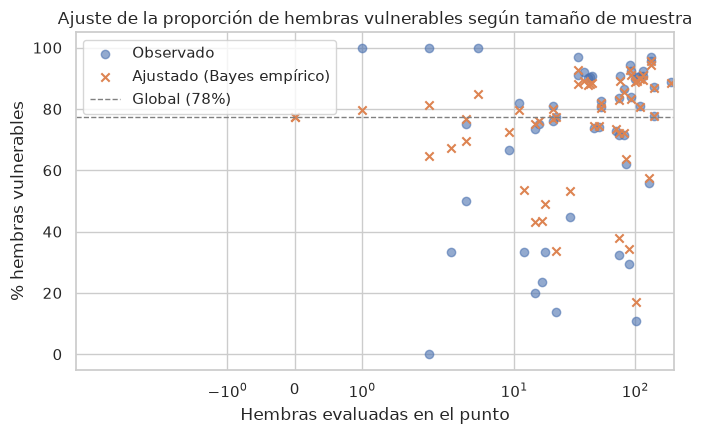

In [8]:
K_PREVIA = 10
p_global = puntos['hembras_vulnerables'].sum() / puntos['hembras_evaluadas'].sum()
puntos['pct_vulnerables'] = ((puntos['hembras_vulnerables'] + K_PREVIA * p_global)
                             / (puntos['hembras_evaluadas'] + K_PREVIA) * 100)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(puntos['hembras_evaluadas'], puntos['pct_vulnerables_obs'], label='Observado', alpha=0.6)
ax.scatter(puntos['hembras_evaluadas'], puntos['pct_vulnerables'], label='Ajustado (Bayes empírico)', marker='x')
ax.axhline(p_global * 100, color='gray', ls='--', lw=1, label=f'Global ({p_global:.0%})')
ax.set_xscale('symlog')
ax.set_xlabel('Hembras evaluadas en el punto')
ax.set_ylabel('% hembras vulnerables')
ax.set_title('Ajuste de la proporción de hembras vulnerables según tamaño de muestra')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Selección de variables

Las variables deben describir **el punto de muestreo** y responder a la pregunta de manejo. Se evaluaron nueve candidatas; la matriz de correlación de Spearman guía qué se descarta por redundancia.

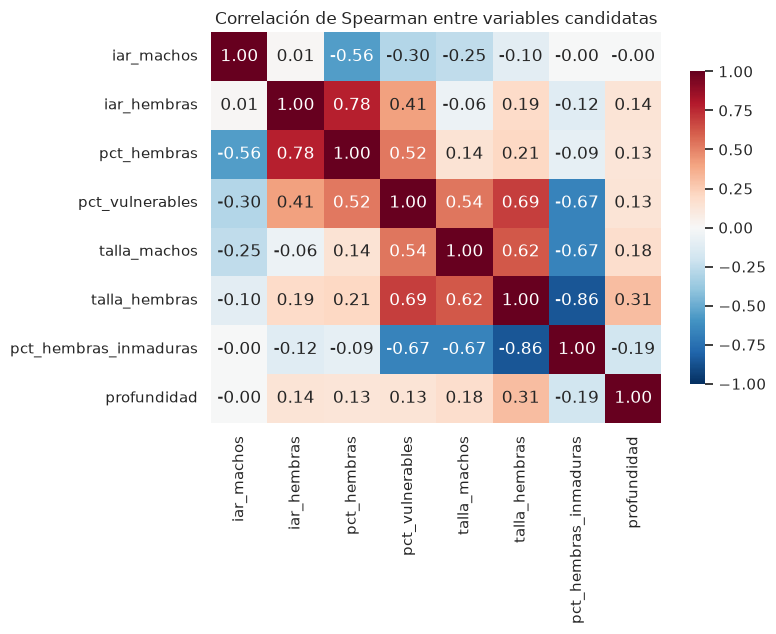

In [9]:
candidatas = ['iar_machos', 'iar_hembras', 'pct_hembras', 'pct_vulnerables', 'talla_machos',
              'talla_hembras', 'pct_hembras_inmaduras', 'profundidad']
corr = puntos[candidatas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlación de Spearman entre variables candidatas')
plt.tight_layout()
plt.show()

**Decisiones:**

| Variable | Decisión | Motivo |
|---|---|---|
| `iar_machos` | ✅ (log) | Densidad de la fracción explotable. Muy asimétrica (asimetría ≈ 1,6), por eso se usa log(1+x). |
| `iar_hembras` | ✅ (log) | Densidad de la fracción protegida (asimetría ≈ 3,2). |
| `talla_machos` | ✅ | Estructura de tallas de la fracción explotable. |
| `pct_vulnerables` | ✅ (ajustada) | Estado reproductivo del punto. |
| `profundidad` | ✅ | Única variable de hábitat disponible. Ver el análisis de sensibilidad en §8. |
| `pct_hembras` | ❌ | Es una función de los dos IAR: $\frac{IAR_h}{IAR_h+IAR_m}$. Incluirla les daría doble peso. |
| `talla_hembras` | ❌ | Correlacionada con `pct_vulnerables` (ρ ≈ 0,69) y con `pct_hembras_inmaduras` (ρ ≈ −0,86). Representa el mismo eje reproductivo. |
| `pct_hembras_inmaduras` | ❌ | Misma información que la anterior. |
| campaña, coordenadas, esfuerzo | ❌ | Se usan para **describir** los grupos, no para formarlos. Si la campaña entrara, los grupos volverían a reproducir las fechas. |

In [10]:
VARIABLES = ['iar_machos', 'iar_hembras', 'talla_machos', 'pct_vulnerables', 'profundidad']


def matriz_modelo(tabla, variables):
    # Aplica log(1+x) a los IAR, imputa la mediana (solo profundidad tiene 1 faltante) y estandariza.
    X = tabla[variables].copy()
    for c in variables:
        if c.startswith('iar'):
            X[c] = np.log1p(X[c])
    X = X.fillna(X.median())
    return StandardScaler().fit_transform(X)


print('Faltantes antes de imputar:', puntos[VARIABLES].isna().sum()[lambda s: s > 0].to_dict())
Z = matriz_modelo(puntos, VARIABLES)
print('Matriz del modelo:', Z.shape)

Faltantes antes de imputar: {'profundidad': 1}
Matriz del modelo: (57, 5)


## 6. ¿Existe una estructura de grupos?

Antes de agrupar hay que comprobar que los datos tengan grupos. Cualquier algoritmo de clustering devuelve grupos aunque los datos sean un continuo, así que se usan tres pruebas complementarias:

1. **Estadístico de Hopkins:** vale ≈ 0,5 si los datos están distribuidos al azar y se acerca a 1 si hay grupos marcados (en la práctica, más de 0,75).
2. **Silhouette contra un modelo nulo:** se permuta cada variable por separado, lo que rompe la relación entre variables pero mantiene sus distribuciones. Luego se compara el silhouette real con el obtenido sobre esos datos permutados.
3. **BIC de mezclas gaussianas para k = 1…5:** si k = 1 gana, no hay evidencia de grupos.

In [11]:
def hopkins(X, m=None, repeticiones=200):
    m = m or max(5, len(X) // 5)
    vecinos = NearestNeighbors(n_neighbors=2).fit(X)
    valores = []
    for _ in range(repeticiones):
        U = rng.uniform(X.min(0), X.max(0), (m, X.shape[1]))
        idx = rng.choice(len(X), m, replace=False)
        u = vecinos.kneighbors(U, 1)[0].sum()
        w = vecinos.kneighbors(X[idx], 2)[0][:, 1].sum()
        valores.append(u / (u + w))
    return np.mean(valores)


def silhouette_nulo(X, k, repeticiones=200):
    valores = []
    for b in range(repeticiones):
        Xp = np.column_stack([rng.permutation(X[:, j]) for j in range(X.shape[1])])
        etiquetas = KMeans(k, n_init=10, random_state=b).fit_predict(Xp)
        valores.append(silhouette_score(Xp, etiquetas))
    return np.percentile(valores, 95)


print(f'Hopkins: {hopkins(Z):.2f}')
bic = pd.DataFrame({cov: [GaussianMixture(k, covariance_type=cov, n_init=10, random_state=SEMILLA).fit(Z).bic(Z)
                          for k in range(1, 6)]
                    for cov in ['diag', 'spherical', 'full']}, index=range(1, 6))
bic.index.name = 'k'
print('\nBIC de mezclas gaussianas (menor = mejor):')
print(bic.round(1))

Hopkins: 0.61



BIC de mezclas gaussianas (menor = mejor):
    diag  spherical   full
k                         
1 849.20     833.10 860.50
2 823.90     837.00 860.90
3 836.30     844.90 886.50
4 856.80     846.30 856.00
5 845.60     807.90 909.10


## 7. Selección del número de grupos y del algoritmo

Para cada k de 2 a 6 se calcula:
- **Silhouette con k-means y con Ward**, comparado con el percentil 95 del modelo nulo.
- **Acuerdo entre algoritmos** (ARI k-means vs. Ward): si dos métodos distintos dan la misma partición, la estructura no depende del método.
- **Estabilidad por bootstrap:** se remuestrean los puntos con reposición, se vuelve a agrupar y se compara con la partición completa (ARI promedio). Esta prueba es más exigente que repetir el ajuste con distintas semillas.

In [12]:
kmeans = lambda X, k: KMeans(k, n_init=50, random_state=SEMILLA).fit_predict(X)
ward = lambda X, k: AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)


def estabilidad_bootstrap(X, k, algoritmo, repeticiones=200):
    completa = algoritmo(X, k)
    ari = []
    for _ in range(repeticiones):
        idx = np.unique(rng.choice(len(X), len(X), replace=True))
        ari.append(adjusted_rand_score(completa[idx], algoritmo(X[idx], k)))
    return np.mean(ari)


filas = []
for k in range(2, 7):
    et_km, et_w = kmeans(Z, k), ward(Z, k)
    filas.append({
        'k': k,
        'silhouette k-means': silhouette_score(Z, et_km),
        'silhouette Ward': silhouette_score(Z, et_w),
        'silhouette nulo (p95)': silhouette_nulo(Z, k, 100),
        'ARI k-means vs Ward': adjusted_rand_score(et_km, et_w),
        'estabilidad k-means': estabilidad_bootstrap(Z, k, kmeans, 100),
        'estabilidad Ward': estabilidad_bootstrap(Z, k, ward, 100),
        'tamaños': np.bincount(et_km).tolist(),
    })
seleccion = pd.DataFrame(filas).set_index('k')
seleccion

,silhouette k-means,silhouette Ward,silhouette nulo (p95),ARI k-means vs Ward,estabilidad k-means,estabilidad Ward,tamaños
k,,,,,,,
2,0.25,0.26,0.22,0.67,0.79,0.67,"[21, 36]"
3,0.23,0.22,0.22,0.40,0.62,0.51,"[20, 17, 20]"
4,0.24,0.21,0.23,0.56,0.58,0.51,"[12, 13, 12, 20]"
5,0.26,0.22,0.23,0.46,0.64,0.56,"[8, 16, 14, 10, 9]"
6,0.25,0.22,0.24,0.54,0.65,0.58,"[14, 7, 9, 9, 6, 12]"


**Lectura de los resultados (§6 y §7):**

- **Estructura de grupos débil.** El Hopkins queda cerca de 0,6, y el silhouette real supera por poco al percentil 95 del modelo nulo. Los puntos de muestreo forman más bien un **gradiente** que tipos bien separados. Este resultado se informa como tal y no se maquilla.
- **El BIC no es concluyente.** Con covarianza diagonal el mínimo está en k = 2; con covarianza completa, k = 1 y k = 2 prácticamente empatan; con covarianza esférica el mínimo está en k = 5, que tiene baja estabilidad. Por eso el BIC no se usa como criterio principal.
- **Por qué k = 2:**
  - es el k más estable en el bootstrap (≈ 0,8);
  - es el k con mayor acuerdo entre k-means y Ward (ARI ≈ 0,67);
  - es donde el silhouette supera con más margen al modelo nulo.

  Con más de 2 grupos la estabilidad cae a alrededor de 0,6 y los algoritmos dejan de coincidir.
- **Algoritmo: k-means.** Es más estable que Ward en todos los k evaluados.
- **k = 3 como refinamiento exploratorio.** Divide uno de los dos grupos (ver §9.3), pero es sensible a la elección de variables (§8), así que no se usa para recomendar.

In [13]:
K_FINAL = 2
puntos['grupo'] = kmeans(Z, K_FINAL)

# Etiquetas descriptivas: el grupo con menor talla media de machos se nombra A.
orden = puntos.groupby('grupo')['talla_machos'].median().sort_values().index
nombres = {orden[0]: 'A · machos chicos', orden[1]: 'B · alta carga reproductiva'}
puntos['grupo'] = puntos['grupo'].map(nombres)
puntos['silhouette'] = silhouette_samples(Z, puntos['grupo'])
puntos['grupo'].value_counts()

grupo
B · alta carga reproductiva    36
A · machos chicos              21
Name: count, dtype: int64

## 8. Análisis de sensibilidad

Una partición útil para el manejo no debería cambiar si se modifica razonablemente la definición de las variables. Se compara la partición final contra variantes plausibles con el ARI: 1 es idéntica y 0 es igual que al azar.

In [14]:
referencia = kmeans(Z, K_FINAL)
puntos_alt = puntos.assign(iar_total=puntos['iar_machos'] + puntos['iar_hembras'])
variantes = {
    'sin profundidad': ['iar_machos', 'iar_hembras', 'talla_machos', 'pct_vulnerables'],
    '+ talla de hembras': VARIABLES + ['talla_hembras'],
    'IAR total + % hembras en lugar de IAR por sexo': ['iar_total', 'pct_hembras', 'talla_machos', 'pct_vulnerables', 'profundidad'],
    '% vulnerables sin ajustar': ['iar_machos', 'iar_hembras', 'talla_machos', 'pct_vulnerables_obs', 'profundidad'],
}
sensibilidad = pd.Series({nombre: adjusted_rand_score(referencia, kmeans(matriz_modelo(puntos_alt, vars_), K_FINAL))
                          for nombre, vars_ in variantes.items()}, name='ARI vs. partición final')
sensibilidad.to_frame()

,ARI vs. partición final
sin profundidad,0.73
+ talla de hembras,0.67
IAR total + % hembras en lugar de IAR por sexo,0.86
% vulnerables sin ajustar,0.86


La partición en dos grupos se mantiene ante todas las variantes (ARI entre 0,67 y 0,86): unos pocos puntos de la frontera cambian de grupo, pero la división general no depende de una elección arbitraria de variables.

## 9. Caracterización de los grupos

In [15]:
perfil_vars = ['iar_machos', 'iar_hembras', 'pct_hembras', 'talla_machos', 'talla_hembras',
               'pct_vulnerables', 'profundidad', 'n_individuos']
perfil = puntos.groupby('grupo')[perfil_vars].median().T
perfil['diferencia (p, Mann-Whitney)'] = [
    stats.mannwhitneyu(*[g[v].dropna() for _, g in puntos.groupby('grupo')]).pvalue for v in perfil_vars]
perfil.loc['n puntos'] = list(puntos['grupo'].value_counts().sort_index()) + [np.nan]
perfil

grupo,A · machos chicos,B · alta carga reproductiva,"diferencia (p, Mann-Whitney)"
iar_machos,31.33,22.46,0.02
iar_hembras,10.30,16.90,0.28
pct_hembras,16.88,43.42,0.02
talla_machos,76.55,84.60,0.00
talla_hembras,64.32,72.14,0.00
pct_vulnerables,64.62,86.06,0.00
profundidad,25.00,32.00,0.01
n_individuos,166.00,139.50,0.00
n puntos,21.00,36.00,NaN


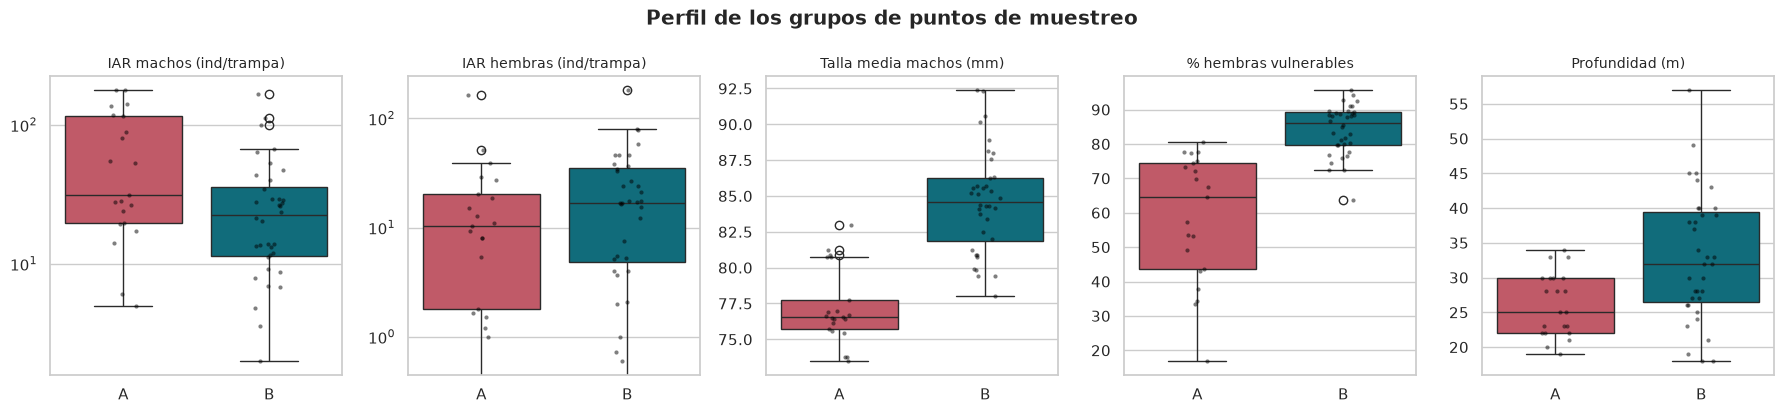

In [16]:
etiquetas_graf = {
    'iar_machos': 'IAR machos (ind/trampa)', 'iar_hembras': 'IAR hembras (ind/trampa)',
    'talla_machos': 'Talla media machos (mm)', 'pct_vulnerables': '% hembras vulnerables',
    'profundidad': 'Profundidad (m)'}
paleta = {'A · machos chicos': '#d1495b', 'B · alta carga reproductiva': '#00798c'}

fig, axes = plt.subplots(1, 5, figsize=(18, 4.2))
for ax, var in zip(axes, VARIABLES):
    sns.boxplot(data=puntos, x='grupo', y=var, hue='grupo', palette=paleta, ax=ax, legend=False)
    sns.stripplot(data=puntos, x='grupo', y=var, color='black', size=3, alpha=0.5, ax=ax)
    if var.startswith('iar'):
        ax.set_yscale('log')
    ax.set_title(etiquetas_graf[var], fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([0, 1], ['A', 'B'])
fig.suptitle('Perfil de los grupos de puntos de muestreo', fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación**

- **Grupo A, machos chicos.**
  - Más machos por trampa, pero de **menor talla** (≈ 77 mm frente a ≈ 85 mm).
  - Menor proporción de hembras en la captura (≈ 17 % frente a ≈ 43 %) y menor proporción de hembras vulnerables.
  - Sitios algo más someros.
  - La densidad de hembras por trampa **no difiere** significativamente entre grupos (p ≈ 0,28). La diferencia está en la *proporción*, por la mayor abundancia de machos.
- **Grupo B, alta carga reproductiva.** Tiene machos más grandes y una proporción muy alta de hembras ovígeras o postovígeras. Es consistente con los núcleos reproductivos identificados en el TP2.

**Sobre las causas:** un patrón como el del grupo A podría deberse a la extracción selectiva de los machos más grandes, o a condiciones del momento del muestreo, como la anomalía reproductiva de 1995–96 descrita en el TP2. En §11 se muestra que el tipo depende fuertemente de la campaña, así que **no se debe leer el grupo A como "zona sobreexplotada"** sin más evidencia. Con datos observacionales y una visita por punto no se puede atribuir una causa.

Los p-valores de la tabla son descriptivos: los grupos se construyeron con estas mismas variables, así que es esperable que difieran.

### 9.1 Ejes de variación (PCA)

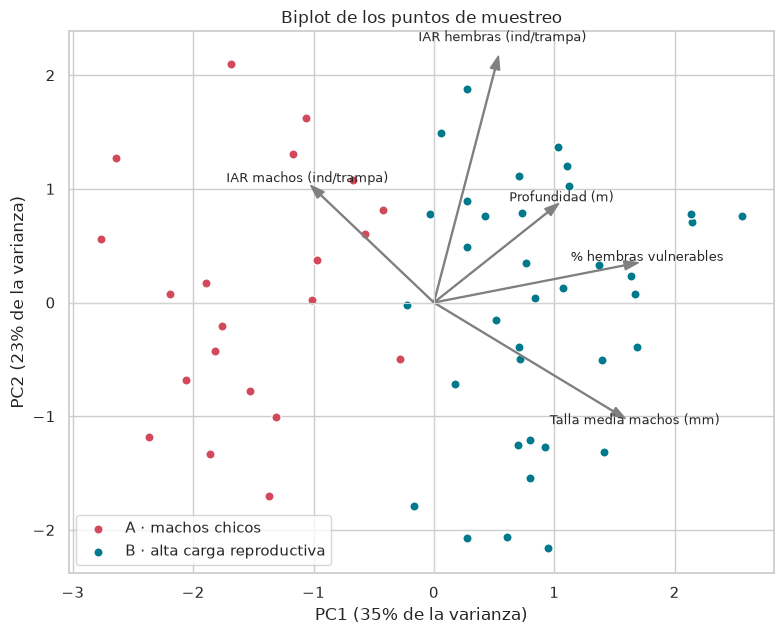

,PC1,PC2
iar_machos,-0.36,0.36
iar_hembras,0.20,0.79
talla_machos,0.57,-0.37
pct_vulnerables,0.61,0.13
profundidad,0.36,0.31


In [17]:
pca = PCA().fit(Z)
coords = pca.transform(Z)
cargas = pd.DataFrame(pca.components_[:2].T, index=VARIABLES, columns=['PC1', 'PC2'])

fig, ax = plt.subplots(figsize=(8, 6.5))
for nombre, color in paleta.items():
    m = (puntos['grupo'] == nombre).values
    ax.scatter(coords[m, 0], coords[m, 1], c=color, label=nombre, s=45, edgecolor='white')
escala = 2.6
for var, (x, y) in cargas.iterrows():
    ax.arrow(0, 0, x * escala, y * escala, color='gray', width=0.008, head_width=0.08)
    ax.text(x * escala * 1.12, y * escala * 1.12, etiquetas_graf[var], fontsize=9, ha='center')
ax.axhline(0, color='lightgray', lw=0.8)
ax.axvline(0, color='lightgray', lw=0.8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} de la varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} de la varianza)')
ax.set_title('Biplot de los puntos de muestreo')
ax.legend()
plt.tight_layout()
plt.show()
cargas

La **PC1** opone puntos con machos grandes y alta proporción de hembras vulnerables a puntos con muchos machos chicos: es el eje *alta carga reproductiva ↔ machos chicos*, y es el que separa los dos grupos. La **PC2** está dominada por la densidad de hembras. Que los grupos se ordenen a lo largo de un eje continuo confirma lo de §6: hay un gradiente, y el corte en dos grupos es una simplificación útil para la gestión.

### 9.2 Puntos de asignación dudosa

In [18]:
dudosos = puntos[puntos['silhouette'] < 0.05].sort_values('silhouette')
print(f'{len(dudosos)} de {len(puntos)} puntos tienen silhouette < 0,05 (en el límite entre grupos):')
dudosos[['campana', 'grupo', 'silhouette'] + VARIABLES]

3 de 57 puntos tienen silhouette < 0,05 (en el límite entre grupos):


,campana,grupo,silhouette,iar_machos,iar_hembras,talla_machos,pct_vulnerables,profundidad
localizacion,,,,,,,,
wp 58,oct_96,A · machos chicos,0.01,5.00,11.10,76.60,80.63,21.00
WP 65,oct_96,B · alta carga reproductiva,0.01,26.25,4.00,78.03,75.98,38.00
wp 166,oct_97,A · machos chicos,0.01,53.33,38.89,81.23,73.44,25.00


Estos puntos están en la frontera entre los dos grupos. En la recomendación conviene tratarlos con el criterio más conservador, es decir, como tipo B.

### 9.3 Refinamiento exploratorio (k = 3)

In [19]:
puntos['grupo_k3'] = kmeans(Z, 3)
print(pd.crosstab(puntos['grupo'], puntos['grupo_k3']))
puntos.groupby('grupo_k3')[VARIABLES].median()

grupo_k3                      0   1   2
grupo                                  
A · machos chicos            20   1   0
B · alta carga reproductiva   0  16  20


,iar_machos,iar_hembras,talla_machos,pct_vulnerables,profundidad
grupo_k3,,,,,
0,42.33,9.84,76.54,61.00,26.50
1,13.60,7.60,85.68,87.75,25.50
2,27.62,20.75,83.92,84.35,39.00


Con k = 3, el grupo A se mantiene casi entero y el grupo B se divide por **profundidad y densidad de hembras**: un subgrupo más profundo (≈ 39 m) con más hembras por trampa y otro más somero y de baja densidad. La división es biológicamente plausible, porque coincide con la batimetría de los núcleos del TP2. Sin embargo, su estabilidad es baja y depende de las variables elegidas (§7–§8), así que se reporta solo como hipótesis para un muestreo futuro.

## 10. Distribución espacial

Seis puntos de ene_96 y abril_96 no tienen coordenadas, así que no aparecen en el mapa (sí en el resto del análisis). El mapa usa coordenadas geográficas sin mapa base, para que el notebook funcione sin conexión.

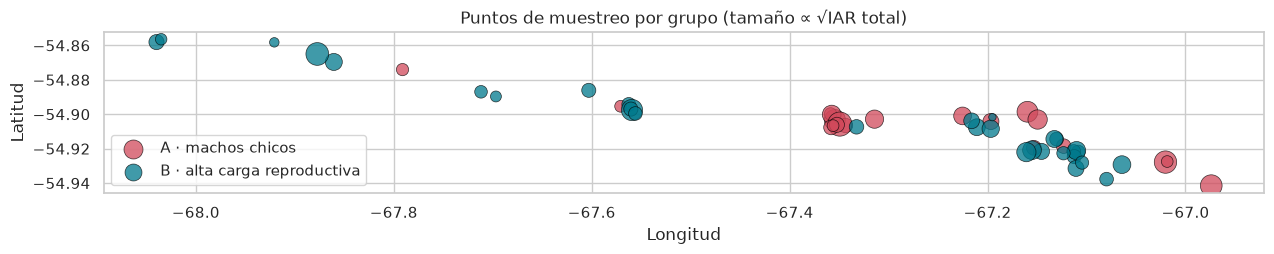

Sin coordenadas: ['N Snipe al traves con la baliza p. de los indios', 'S islote Belgrano/punta navarro', 'SW Ilote Belgrano', 'cerca de Haskesheska', 'frente bal. Ponsatti', 'traves Snipe - P.Indios']


In [20]:
con_coord = puntos.dropna(subset=['latitud', 'longitud'])
fig, ax = plt.subplots(figsize=(13, 4.5))
for nombre, color in paleta.items():
    g = con_coord[con_coord['grupo'] == nombre]
    ax.scatter(g['longitud'], g['latitud'], s=np.sqrt(g['iar_machos'] + g['iar_hembras']) * 18,
               c=color, alpha=0.75, edgecolor='black', linewidth=0.5, label=nombre)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Puntos de muestreo por grupo (tamaño ∝ √IAR total)')
ax.set_aspect(1 / np.cos(np.radians(con_coord['latitud'].mean())))
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()
print(f'Sin coordenadas: {sorted(set(puntos.index) - set(con_coord.index))}')

## 11. Variabilidad temporal

### 11.1 El problema y cómo se resuelve

**Ningún nombre de localización se repite entre campañas.** Si se analiza por nombre, el lugar y la fecha quedan totalmente confundidos. Pero muchos puntos de campañas distintas están **muy cerca entre sí**. Se definen entonces **zonas espaciales**: grupos de puntos cuyo diámetro máximo es de 2 km, obtenidos con un agrupamiento jerárquico de enlace completo sobre las coordenadas en kilómetros.

El enlace completo garantiza que ningún par de puntos de una misma zona esté a más de 2 km. Esa es una escala razonable para una unidad de manejo: puede delimitarse como polígono de resguardo y es más chica que la separación entre los sectores del canal.

In [21]:
R_TIERRA_KM = 6371
lat0 = np.radians(con_coord['latitud'].mean())
xy_km = np.column_stack([
    R_TIERRA_KM * np.cos(lat0) * np.radians(con_coord['longitud']),
    R_TIERRA_KM * np.radians(con_coord['latitud'])])

DIAMETRO_ZONA_KM = 2.0
zonas = fcluster(linkage(xy_km, method='complete'), DIAMETRO_ZONA_KM, criterion='distance')
puntos.loc[con_coord.index, 'zona'] = zonas

campanas_por_zona = puntos.groupby('zona')['campana'].nunique()
zonas_multi = campanas_por_zona[campanas_por_zona > 1].index
print(f'Zonas: {len(campanas_por_zona)}  |  visitadas en más de una campaña: {len(zonas_multi)} '
      f'({puntos["zona"].isin(zonas_multi).sum()} puntos)')

# Sensibilidad del umbral
for d in [1.0, 1.5, 2.0, 3.0]:
    z = fcluster(linkage(xy_km, method='complete'), d, criterion='distance')
    s = pd.Series(con_coord['campana'].values).groupby(z).nunique()
    print(f'  diámetro {d:.1f} km → {s.size} zonas, {(s > 1).sum()} con más de una campaña')

Zonas: 17  |  visitadas en más de una campaña: 8 (38 puntos)
  diámetro 1.0 km → 26 zonas, 10 con más de una campaña
  diámetro 1.5 km → 20 zonas, 10 con más de una campaña
  diámetro 2.0 km → 17 zonas, 8 con más de una campaña
  diámetro 3.0 km → 14 zonas, 6 con más de una campaña


In [22]:
# Se numeran las zonas de oeste a este para facilitar la lectura.
orden_oe = puntos.groupby('zona')['longitud'].mean().sort_values().index
puntos['zona'] = puntos['zona'].map({z: f'Z{i + 1:02d}' for i, z in enumerate(orden_oe)})

tabla_zonas = (puntos[puntos['zona'].notna()]
               .pivot_table(index='zona', columns='campana', values='grupo',
                            aggfunc=lambda s: ''.join(sorted(x[0] for x in s)), observed=False)
               .fillna(''))
print('Grupo de cada punto por zona (oeste → este) y campaña:')
tabla_zonas[tabla_zonas.ne('').sum(axis=1) > 1]

Grupo de cada punto por zona (oeste → este) y campaña:


campana,ene_96,abril_96,jul_96,oct_96,jul_97,oct_97,oct_98
zona,,,,,,,
Z07,,,,A,,,BBBB
Z08,,,AAAAAA,A,,AB,
Z10,,,,AAB,,BB,B
Z11,,,,A,,,A
Z12,,,,,,AB,BB
Z13,,,,B,B,,
Z14,,,,BB,B,ABB,BB
Z15,,,,,,B,B


Cada celda muestra el grupo (A o B) de cada punto de esa zona en esa campaña. El tipo **no es un atributo fijo del lugar**:
- **Zonas estables:** Z11 se mantiene A, y Z13 y Z15 se mantienen B.
- **Zonas que cambian:** Z07 y Z10 son mayoritariamente A en oct_96 y pasan a B en oct_98 (Z10 ya es B en jul_97).
- **Zonas mixtas:** el resto combina ambos tipos.

La siguiente celda mide qué tan asociada está la tipología con la campaña.

In [23]:
def v_cramer(a, b):
    tabla = pd.crosstab(a, b)
    chi2 = stats.chi2_contingency(tabla)[0]
    return np.sqrt(chi2 / (tabla.values.sum() * (min(tabla.shape) - 1)))


v_obs = v_cramer(puntos['grupo'], puntos['campana'].astype(str))
v_nulo = [v_cramer(rng.permutation(puntos['grupo'].values), puntos['campana'].astype(str).values)
          for _ in range(2000)]
print(f'V de Cramér grupo × campaña: {v_obs:.2f}  (p por permutación = {np.mean(np.array(v_nulo) >= v_obs):.3f})')
pd.crosstab(puntos['campana'], puntos['grupo'])

V de Cramér grupo × campaña: 0.59  (p por permutación = 0.001)


grupo,A · machos chicos,B · alta carga reproductiva
campana,,
ene_96,1,4
abril_96,0,1
jul_96,7,0
oct_96,5,4
jul_97,3,7
oct_97,4,7
oct_98,1,13


**La tipología está fuertemente asociada a la campaña.** Todos los puntos de jul_96 son tipo A, y en oct_98 casi todos son tipo B. Puede haber dos explicaciones, y no son excluyentes:

1. **Distribución espacial distinta en cada campaña:** cada campaña muestreó sectores distintos del canal.
2. **Un cambio real en el tiempo:** por ejemplo, la anomalía reproductiva de 1995–96 descrita en el TP2.

Para separarlas hay que comparar **la misma zona en el mismo mes** de años distintos.

### 11.2 Misma zona y mismo mes, años distintos (octubre de 1996 frente a octubre de 1998)

In [24]:
octubres = puntos[puntos['campana'].isin(['oct_96', 'oct_98']) & puntos['zona'].notna()]
zonas_ambos = octubres.groupby('zona')['campana'].nunique()[lambda s: s == 2].index
comparacion = (octubres[octubres['zona'].isin(zonas_ambos)]
               .groupby(['zona', 'campana'], observed=True)[['talla_machos', 'pct_vulnerables', 'iar_machos', 'iar_hembras']]
               .median()
               .unstack('campana'))
for var in ['talla_machos', 'pct_vulnerables']:
    comparacion[(var, 'cambio')] = comparacion[(var, 'oct_98')] - comparacion[(var, 'oct_96')]
comparacion.round(1)

talla_machos        pct_vulnerables        iar_machos         \
campana       oct_96 oct_98          oct_96 oct_98     oct_96 oct_98   
zona                                                                   
Z07            80.80  91.40           16.90  78.70       6.10  28.60   
Z10            76.40  83.80           77.50  88.00      55.30  34.40   
Z11            76.70  75.70           64.60  75.00     115.00 141.00   
Z14            81.80  85.30           67.90  76.70      13.30  37.10   

        iar_hembras        talla_machos pct_vulnerables  
campana      oct_96 oct_98       cambio          cambio  
zona                                                     
Z07           10.30   2.20        10.70           61.80  
Z10            0.60  16.80         7.40           10.40  
Z11            1.50  15.00        -1.00           10.40  
Z14           14.70   3.60         3.50            8.80

En las 4 zonas visitadas en ambos octubres, en 1998 la **proporción de hembras vulnerables aumentó en todas** y la **talla de los machos aumentó en 3 de 4** (en la restante se mantuvo). Como se compara el mismo mes en la misma zona, el cambio **no puede atribuirse a la estacionalidad ni a una diferencia de sector**: es un cambio entre años.

Es consistente con una recuperación reproductiva después de la anomalía de 1995–96. Con 4 zonas el resultado es **descriptivo y no permite inferencia estadística**, pero es la evidencia temporal más limpia que ofrecen estos datos.

### 11.3 ¿Pesa más el lugar o el momento?

Para las zonas visitadas en más de una campaña se descompone la variabilidad de cada variable entre **zona** y **campaña** con un ANOVA de dos factores sin interacción (tipo II). Con tan pocas observaciones por celda no se puede estimar la interacción, así que se informa el **η² parcial** de cada factor como medida descriptiva del tamaño del efecto.

In [25]:
def eta2_parcial(tabla, variable):
    # ANOVA de dos factores (zona, campaña) sin interacción, resuelto por mínimos cuadrados.
    datos = tabla[[variable, 'zona', 'campana']].dropna().copy()
    datos['campana'] = datos['campana'].astype(str)
    y = datos[variable].values

    def sce(columnas):
        X = pd.get_dummies(datos[columnas], drop_first=True).astype(float)
        X.insert(0, 'const', 1.0)
        beta, *_ = np.linalg.lstsq(X.values, y, rcond=None)
        return ((y - X.values @ beta) ** 2).sum()

    sce_completo = sce(['zona', 'campana'])
    return {'zona': (sce(['campana']) - sce_completo) / (sce(['campana']) - sce_completo + sce_completo),
            'campaña': (sce(['zona']) - sce_completo) / (sce(['zona']) - sce_completo + sce_completo),
            'n puntos': len(datos)}


multi = puntos[puntos['zona'].isin(puntos.groupby('zona')['campana'].nunique()[lambda s: s > 1].index)].copy()
multi['log_iar_machos'] = np.log1p(multi['iar_machos'])
multi['log_iar_hembras'] = np.log1p(multi['iar_hembras'])
descomp = pd.DataFrame({v: eta2_parcial(multi, v) for v in
                        ['log_iar_machos', 'log_iar_hembras', 'talla_machos', 'pct_vulnerables', 'profundidad']}).T
descomp.columns = ['η² parcial zona', 'η² parcial campaña', 'n puntos']
descomp

,η² parcial zona,η² parcial campaña,n puntos
log_iar_machos,0.39,0.34,38.00
log_iar_hembras,0.13,0.28,38.00
talla_machos,0.47,0.32,38.00
pct_vulnerables,0.29,0.41,38.00
profundidad,0.52,0.25,38.00


### 11.4 Variación entre campañas

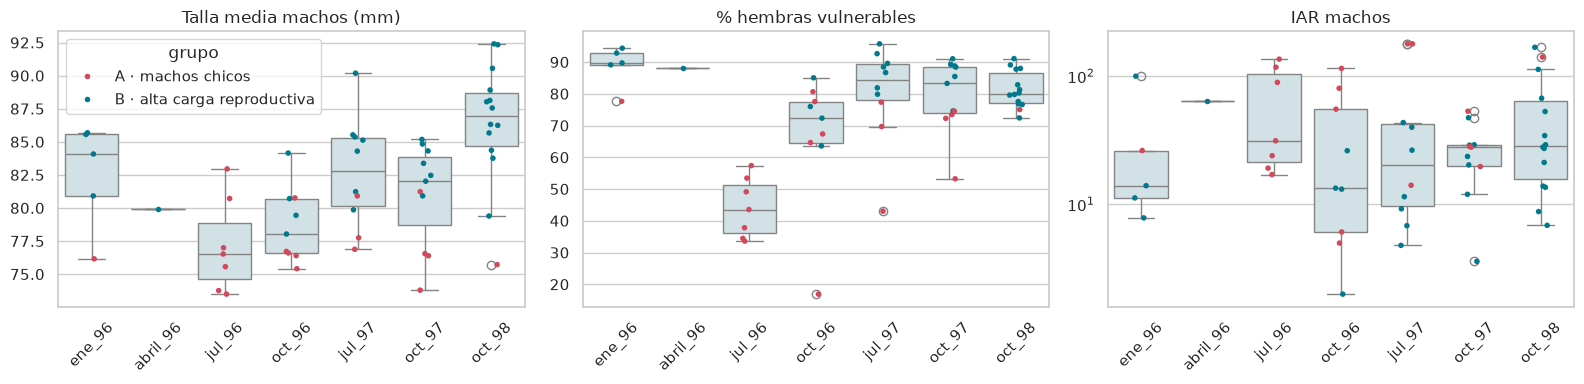

,puntos,pct_grupo_B,iar_machos,iar_hembras,talla_machos,pct_vulnerables
campana,,,,,,
ene_96,5,80.00,14.00,46.50,84.08,89.71
abril_96,1,100.00,64.00,17.50,79.91,88.08
jul_96,7,0.00,31.33,12.78,76.52,43.54
oct_96,9,44.44,13.40,4.00,78.03,72.33
jul_97,10,70.00,20.31,20.75,82.76,84.27
oct_97,11,63.64,27.96,33.00,82.02,83.26
oct_98,14,92.86,28.60,5.19,86.94,80.02


In [26]:
por_campana = puntos.groupby('campana', observed=True).agg(
    puntos=('grupo', 'size'),
    pct_grupo_B=('grupo', lambda s: (s.str.startswith('B')).mean() * 100),
    iar_machos=('iar_machos', 'median'),
    iar_hembras=('iar_hembras', 'median'),
    talla_machos=('talla_machos', 'median'),
    pct_vulnerables=('pct_vulnerables', 'median'))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, var, titulo in zip(axes, ['talla_machos', 'pct_vulnerables', 'iar_machos'],
                           ['Talla media machos (mm)', '% hembras vulnerables', 'IAR machos']):
    sns.boxplot(data=puntos, x='campana', y=var, color='#cfe3e8', ax=ax, order=ORDEN_CAMPANAS)
    sns.stripplot(data=puntos, x='campana', y=var, hue='grupo', palette=paleta, ax=ax,
                  order=ORDEN_CAMPANAS, size=4, legend=ax is axes[0])
    ax.set_title(titulo)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45)
    if var.startswith('iar'):
        ax.set_yscale('log')
plt.tight_layout()
plt.show()
por_campana

**Interpretación de la variabilidad temporal:**

- **Variables que dependen más de la zona (§11.3):** la talla de los machos (η² parcial 0,47 contra 0,32), la densidad de machos (0,39 contra 0,34) y la profundidad, que es la variable más claramente espacial. Son las que más sirven para delimitar áreas.
- **Variables que dependen más de la campaña:** la proporción de hembras vulnerables (0,41 contra 0,29) y la densidad de hembras (0,28 contra 0,13). El estado reproductivo **cambia en el tiempo más que en el espacio**, y eso coincide con lo visto en el TP2: en 1996 hubo muchas hembras maduras sin huevos.
- **Evidencia temporal más sólida:** la comparación de octubres (§11.2) muestra que las zonas visitadas en 1996 y en 1998 tenían en 1998 una carga reproductiva más alta y machos más grandes.
- **Lo que no se puede concluir:** con campañas que no repiten mes todos los años, no se puede estimar la **estacionalidad** (enero, abril y julio aparecen una o dos veces, en zonas distintas). Con 3 años tampoco se puede hablar de una **tendencia** de largo plazo.

## 12. Recomendación para el gobierno local

Las recomendaciones se ordenan según la solidez de la evidencia que las respalda.

**1. Mantener la tolerancia cero de hembras y complementarla con manejo espacial** *(evidencia sólida)*
En los puntos tipo B (36 de 57), la mediana de hembras ovígeras o postovígeras es del 86 %. Devolver las hembras al agua no evita la pérdida de huevos ni la mortalidad por manipulación. Por eso, en las zonas que se mantienen como tipo B en más de una campaña (Z13, Z15 y la mayor parte de Z14 y Z12), se recomienda **limitar el calado de trampas en los meses de eclosión y cópula** o **fijar cupos de esfuerzo más bajos**. Los puntos de asignación dudosa (§9.2) se tratan como tipo B.

**2. Vigilar las zonas persistentemente tipo A** *(evidencia moderada)*
Zonas como Z11 (tipo A en los dos octubres) y Z08 (mayoritariamente A en tres campañas) combinan una alta densidad de machos con tallas menores en más de un año. Esa persistencia es la que justifica atención: un tipo A aislado puede reflejar el momento del muestreo (§11.1). Para estas zonas se recomienda:
- controlar en puerto que se cumpla la talla mínima de desembarque;
- evaluar un **tope de esfuerzo** si el monitoreo (punto 3) confirma que la talla sigue bajando.

**3. Establecer un programa de monitoreo con estaciones fijas** *(condición para todo lo anterior)*
Hoy ningún punto fue muestreado dos veces, y las campañas no repiten mes. Se recomienda definir **estaciones fijas** dentro de las zonas de §11, muestreadas en la **misma época todos los años**, con un **protocolo de esfuerzo estandarizado** (solo trampas, número registrado por lance). Sin esto, no se puede evaluar si las medidas funcionan.

**4. Revisar la información con datos actuales antes de aplicar polígonos concretos**
Los datos son de 1996–1998. La recomendación define **criterios** para delimitar áreas, pero los polígonos concretos deberían calibrarse con información reciente de la flota y de campañas científicas.

## 13. Limitaciones

| Limitación | Efecto sobre las conclusiones |
|---|---|
| Estructura de grupos débil (Hopkins ≈ 0,6) | Los grupos son una simplificación de un gradiente; los puntos dudosos (§9.2) deben tratarse con criterio conservador. |
| Una sola visita por punto y campañas irregulares | La variabilidad temporal se analiza por zonas y no permite separar estacionalidad de tendencia. |
| La tipología depende de la campaña (V de Cramér ≈ 0,6) | Un punto tipo A puede reflejar el momento del muestreo y no el lugar; solo las zonas persistentes justifican medidas espaciales. |
| Selectividad de las trampas (casi sin machos juveniles) | No se pueden identificar áreas de cría de machos. |
| Equivalencia 1 línea = 10 trampas sin respaldo documental | Si fuera incorrecta, el IAR de los lances con líneas se escalaría proporcionalmente; debería confirmarse con la mentora. |
| Pérdida de ≈ 30 % de registros por falta de ubicación (TP2) | Si la pérdida no es aleatoria entre campañas, puede sesgar la comparación temporal. |
| Datos de hace casi 30 años | Las conclusiones valen como metodología y diagnóstico histórico, no como estado actual del recurso. |

## 14. Alternativas evaluadas y descartadas

| Enfoque | Resultado | Motivo del descarte |
|---|---|---|
| Clustering de individuos (FAMD + HDBSCAN) | 28 grupos y 21 % de ruido | La unidad no es la que pide la consigna; los grupos reproducen lances. |
| Clustering de individuos (FAMD + Ward, k = 5) | Grupos alineados con campaña y perfil | Las 5 componentes retienen el 47 % de la varianza; k elegido sin criterio. |
| k-prototypes con la localización como variable | Clusters = campañas (por ejemplo, ene_96 + abril_96 en un grupo) | La localización y la fecha dominan la distancia; no aporta información nueva. |
| Talla legal de 80 mm como corte | Divide a los machos casi a la mitad | Sin fuente documentada; se reemplazó por la talla como variable continua. |
| k ≥ 3 sobre puntos de muestreo | Estabilidad ≈ 0,6 y desacuerdo entre algoritmos | No hay evidencia suficiente; k = 3 se reporta solo como exploratorio. |